In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score	
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
print(np.__version__)
print(pd.__version__)

1.26.4
3.0.0


In [3]:
# !pip install --upgrade numpy pandas matplotlib

In [3]:
df = pd.read_csv(r"C:\Users\TRIDEV PAL\Documents\Capstone project\flipkart_mens_topwear_1000_records.csv")

In [4]:
df.head()

,name,company,price,original_price,discount,offers,size,url,page
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,₹ 298,₹ 999,70% off,Hot Deal,NaN,https://www.flipkart.com/kajaru-solid-men-zip-...,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,₹ 338,₹ 999,66% off,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-printed-men-pol...,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,₹ 459,"₹ 1,999",77% off,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-solid-men-round...,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,₹ 306,₹ 999,69% off,Only few left,NaN,https://www.flipkart.com/try-striped-men-zip-n...,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,₹ 192,"₹ 1,999",90% off,Hot Deal,NaN,https://www.flipkart.com/tripr-solid-men-henle...,1


In [5]:
df.isnull().sum()

name                 0
company              0
price                0
original_price       6
discount             9
offers              49
size              1000
url                  0
page                 0
dtype: int64

In [6]:
df.shape

(1000, 9)

In [7]:
df.columns

Index(['name', 'company', 'price', 'original_price', 'discount', 'offers',
       'size', 'url', 'page'],
      dtype='str')

In [8]:
df.dtypes

name                  str
company               str
price                 str
original_price        str
discount              str
offers                str
size              float64
url                   str
page                int64
dtype: object

In [9]:
df.info

<bound method DataFrame.info of                                                   name      company  price  \
0        Men Solid Zip Neck Cotton Blend Black T-Shirt       KAJARU  ₹ 298   
1    Men Printed Polo Neck Cotton Blend Black, Grey...        TRIPR  ₹ 338   
2    Pack of 4 Men Solid Round Neck Cotton Blend Mu...        TRIPR  ₹ 459   
3    Men Striped Zip Neck Cotton Blend Black, White...     Try This  ₹ 306   
4     Men Solid Henley Neck Cotton Blend Black T-Shirt        TRIPR  ₹ 192   
..                                                 ...          ...    ...   
995      Men Solid Polo Neck Cotton Blend Blue T-Shirt     CANTABIL  ₹ 390   
996  Men Striped Round Neck Polyester Grey, White T...        Force  ₹ 243   
997  Men Regular Fit Checkered Button Down Collar C...     RED TAPE  ₹ 629   
998  Men's Tshirt Men Printed, Typography Round Nec...    BlueFicus  ₹ 325   
999   Men Regular Fit Solid Curved Collar Formal Shirt  youth first  ₹ 206   

    original_price discount    

In [10]:
df.describe()

,size,page
count,0.0,1000.000000
mean,NaN,13.000000
std,NaN,7.214711
min,NaN,1.000000
25%,NaN,7.000000
50%,NaN,13.000000
75%,NaN,19.000000
max,NaN,25.000000


### PHASE 4 : MACHINE LEARNING MODEL

##### • Recommendation -> Suggest similar items

In [65]:
features = ['name', 'company', 'price_band', 'discount_pct']
df_model = df[features].copy()

In [66]:
df_model['discount_pct'] = df_model['discount_pct'].astype(str)

In [67]:
df_model['combined_features'] = (
    df_model['name'] + " " +
    df_model['company'] + " " +
    df_model['price_band'] + " " +
    df_model['discount_pct']
)

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
feature_matrix = vectorizer.fit_transform(df_model['combined_features'])

In [69]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix)

In [70]:
def recommend(query, top_n=5):
    query = str(query).lower()
    
    # Search across multiple columns
    mask = (
        df['name'].astype(str).str.lower().str.contains(query) |
        df['company'].astype(str).str.lower().str.contains(query) |
        df['price'].astype(str).str.contains(query) |
        df['discount_pct'].astype(str).str.contains(query)
    )
    
    indices = df[mask].index
    
    if len(indices) == 0:
        return "Item not found!"
    
    idx = indices[0]
    
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    product_indices = [i[0] for i in scores]
    
    return df[['name','company','price','discount_pct']].iloc[product_indices]


In [71]:
unique_price = df.price.unique()

In [72]:
df.price.unique()

array([ 298.,  338.,  459.,  306.,  192.,  285.,  210.,  237.,  266.,
        260.,  270.,  594.,  350.,  393.,  256.,  241.,  392.,  262.,
        416.,  318.,  226.,  252.,  220.,  446.,  998.,  322.,  243.,
        236.,  163.,  240.,  475.,  276.,  752.,  148.,  394.,  610.,
        267.,  234.,  431.,  313.,  219.,  328.,  235.,  263.,  337.,
        385.,  421.,  336.,  665.,  319.,  229.,  374.,  246.,  214.,
        211.,  289.,  212.,  255.,  265.,  420.,  282.,  367.,  250.,
        218.,  305.,  205.,  172.,  360.,  249.,  290.,  283.,  629.,
        295.,  291.,  280.,  442.,  457.,  277.,  507.,  608.,  354.,
        300.,  499.,  315.,  434.,  399.,  273.,  479.,  253.,  368.,
        180.,  232.,  228.,  120.,  248.,  330.,  329.,  391.,  452.,
        261.,  317.,  759.,  224.,  202.,  242.,  178.,  437.,  884.,
        175.,  279.,  372.,  388.,  436.,  308.,  207.,  450.,  410.,
        358.,  221.,  223.,  183.,  389.,  222.,  258.,  559.,  435.,
        662.,  440.,

In [73]:
df['discount_pct'].sort_values(ascending=False).unique()

array([9.309e+01, 9.048e+01, 9.040e+01, 8.989e+01, 8.974e+01, 8.949e+01,
       8.944e+01, 8.939e+01, 8.934e+01, 8.924e+01, 8.909e+01, 8.899e+01,
       8.885e+01, 8.884e+01, 8.881e+01, 8.879e+01, 8.874e+01, 8.870e+01,
       8.869e+01, 8.859e+01, 8.848e+01, 8.834e+01, 8.829e+01, 8.824e+01,
       8.821e+01, 8.819e+01, 8.804e+01, 8.799e+01, 8.794e+01, 8.784e+01,
       8.780e+01, 8.773e+01, 8.769e+01, 8.760e+01, 8.755e+01, 8.739e+01,
       8.737e+01, 8.734e+01, 8.733e+01, 8.699e+01, 8.674e+01, 8.672e+01,
       8.669e+01, 8.668e+01, 8.649e+01, 8.644e+01, 8.639e+01, 8.634e+01,
       8.630e+01, 8.627e+01, 8.619e+01, 8.610e+01, 8.609e+01, 8.599e+01,
       8.592e+01, 8.580e+01, 8.579e+01, 8.574e+01, 8.562e+01, 8.549e+01,
       8.532e+01, 8.526e+01, 8.523e+01, 8.519e+01, 8.510e+01, 8.509e+01,
       8.499e+01, 8.488e+01, 8.486e+01, 8.468e+01, 8.459e+01, 8.453e+01,
       8.448e+01, 8.446e+01, 8.437e+01, 8.432e+01, 8.431e+01, 8.418e+01,
       8.409e+01, 8.407e+01, 8.406e+01, 8.405e+01, 

In [74]:
recommend("Men Regular Fit Checkered Button Down Collar C")

,name,company,price,discount_pct
834,Men Regular Fit Checkered Button Down Collar C...,RED TAPE,610.0,81.51
34,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
157,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
197,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
437,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51


In [75]:
recommend("319")

,name,company,price,discount_pct
122,Men Regular Fit Solid Spread Collar Casual Shirt,METRONAUT PLUS,457.0,83.07
592,Men Solid Round Neck Cotton Blend Black T-Shirt,BLIVE,223.0,77.68
99,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,305.0,66.07
139,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,305.0,66.07
942,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,309.0,69.07


In [76]:
recommend("7.9")

,name,company,price,discount_pct
136,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
177,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
417,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
776,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
814,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94


In [77]:
recommend("Try This")

,name,company,price,discount_pct
95,Men Striped Zip Neck Cotton Blend Brown T-Shirt,Try This,306.0,69.37
838,"Men Checkered Zip Neck Cotton Blend White, Bla...",Try This,285.0,71.47
919,Men Colorblock Zip Neck Cotton Blend Black T-S...,Try This,240.0,75.98
855,Men Striped Zip Neck Cotton Blend Brown T-Shirt,Try This,287.0,71.27
449,Men Checkered Zip Neck Cotton Blend Dark Green...,Try This,287.0,71.27


In [78]:
df.company.unique()

<ArrowStringArray>
[                   'KAJARU',                     'TRIPR',
                  'Try This',                     'Surhi',
                    'VeBNoR',                   'N AND J',
                 'JACKBELLA',                     'DIMMY',
                   'Raymond',                     'WOXEN',
 ...
                 'Southcity',               'Tee Gallery',
                      'DBAX',                   'GLAUCUS',
 'United Colors of Benetton',                'BLUE SQUAD',
                'PrintHolic',                 'Lux Nitro',
                'hkCreation',                 'BlueFicus']
Length: 190, dtype: str

## Train–Test Split -> Model Training -> Evaluation (Accuracy/RMSE/R²)

In [79]:
from sklearn.model_selection import train_test_split

X = df[['original_price', 'discount_pct', 'company', 'page']]
y = df['price']

In [80]:
X = pd.get_dummies(X, columns=['company'], drop_first=True)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = model.predict(X_test)

In [84]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 29.968378939548487
R² Score: 0.9339899426650998


C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [108]:
train_score = model.score(X_train, y_train)
print("Training Score:", train_score)

Training Score: 0.9632903094507861


In [109]:
test_score = model.score(X_test, y_test)
print("Testing Score:", test_score)

Testing Score: 0.9339899426650998


In [85]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,459.0,399.856464
1,392.0,387.401691
2,393.0,394.705391
3,393.0,394.165069
4,393.0,392.544103
5,382.0,316.031325
6,475.0,473.591820
7,276.0,361.583190
8,279.0,282.668245
9,241.0,270.102677


In [86]:
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 29.968378939548487
R² Score: 0.9339899426650998


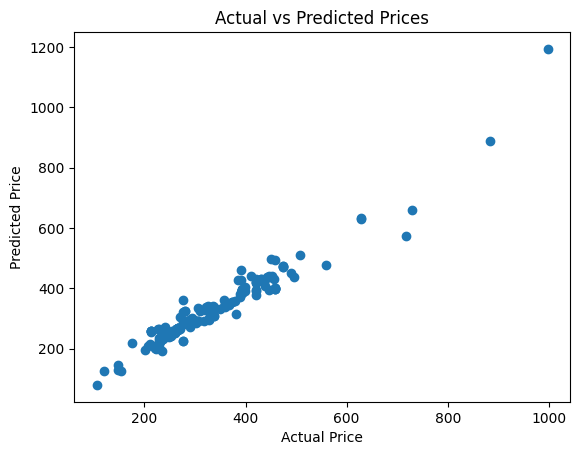

In [87]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

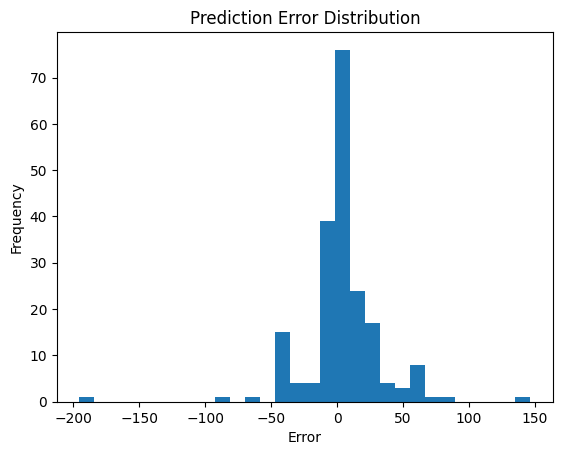

In [88]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [89]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
172,company_WROGN,348.203592
152,company_U.S. POLO ASSN.,301.046858
116,company_Raymond,210.876294
128,company_Snitch,195.550954
160,company_VAN HEUSEN,164.548595
77,company_LOUIS PHILIPPE,144.210243
136,company_THE BEAR HOUSE,137.952556
16,company_Allen Cooper,133.468903
53,company_HERE&NOW,129.247473
99,company_PARK AVENUE,122.303218


In [90]:
# The high R² score indicates strong linear dependency between price
# and features such as original price and discount, which is expected in pricing models.

In [91]:
df.head()

,name,company,price,original_price,discount,offers,url,page,discount_pct,savings,price_band,high_discount
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,298.0,999.0,70.0,Hot Deal,https://www.flipkart.com/kajaru-solid-men-zip-...,1,70.17,701.0,Budget,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,338.0,999.0,66.0,"Buy 2 items, save extra 5%",https://www.flipkart.com/tripr-printed-men-pol...,1,66.17,661.0,Budget,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,459.0,1999.0,77.0,"Buy 2 items, save extra 5%",https://www.flipkart.com/tripr-solid-men-round...,1,77.04,1540.0,Budget,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,306.0,999.0,69.0,Only few left,https://www.flipkart.com/try-striped-men-zip-n...,1,69.37,693.0,Budget,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,192.0,1999.0,90.0,Hot Deal,https://www.flipkart.com/tripr-solid-men-henle...,1,90.40,1807.0,Budget,1


In [92]:
df.high_discount.to_csv("df.high_discount.csv",index=False)

In [93]:
df.discount_pct.to_csv('df.discount_pct.csv',index=False)

In [94]:
df.price_band.to_csv('df.df.price_band.csv',index=False)

In [95]:
df.savings.to_csv('df.savings.csv',index=False)

In [96]:
company_savings.to_csv('company_savings.csv')

In [97]:
company_discount_pact.to_csv('df.company_discount_pact.csv',index=False)

In [98]:
pd.DataFrame(unique_price).to_csv('unique_price.csv')

In [99]:
results.to_csv('results.csv', index=False)

In [100]:
coefficients.to_csv("coefficients.csv", index=False)

In [101]:
df.to_csv("df.csv",index=False)